# Module 19: Random Walk Statistics and the Binomial Distribution

## Learning Objectives
By the end of this module you should be able to:
1. Slice a 2D NumPy array to extract particle positions at a specific timestep
2. Plot normalized histograms and interpret them as probability distributions evolving in time
3. Compute ensemble mean and standard deviation using `np.mean` and `np.std` with the correct `axis` argument
4. Explain qualitatively why the spread of random-walk particles grows as $\\sqrt{N}$
5. Simulate the binomial distribution with `rng.binomial` and describe its shape and parameters
6. Convert a binomial sample to a random-walk final-position distribution and verify the $\\sqrt{N}$ spread

---

## Background

In Module 18 we built increasingly efficient code for simulating many 1D random-walk particles simultaneously. The final version, `rw_multi2`, generates a 2D array of shape `(Np, Nstep)` where each row is one particle's full trajectory.

Now we shift attention from *how to simulate* to *what the simulation tells us*. Two key questions:

1. **How does the position distribution of an ensemble of particles change over time?**  
   Particles start clustered at the origin, then spread outward. The distribution at step $n$ is approximately Gaussian with mean $\\mu = 0$ and standard deviation $\\sigma = \\sqrt{n}$.

2. **Why $\\sqrt{n}$?**  
   Each step is an independent $\\pm 1$ coin flip. The final position after $n$ steps is the sum of $n$ independent random variables — the situation described by the **binomial distribution** — and the standard deviation of that sum scales as $\\sqrt{n}$.

Understanding this connection between random walk, the binomial distribution, and ultimately the **Central Limit Theorem** is the goal of this module.

---

## Setup: Rebuild `rw_multi2`

We start from the fully-vectorized multi-particle random-walk function from Module 18. Run the cell below — we will reuse `rmulti` throughout this notebook.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def rw_multi2(Np, N):
    N  = int(N)
    Np = int(Np)
    rng = np.random.default_rng()
    hop    = rng.choice([-1, 1], [Np, N])
    rmulti = np.cumsum(hop, axis=1)
    return rmulti

rmulti = rw_multi2(1e4, 1e3)   # 10 000 particles, 1 000 steps each
print("Shape of rmulti:", rmulti.shape)  # should be (10000, 1000)

Shape of rmulti: (10000, 1000)


---

## Part 1: Position Distributions at Different Timesteps

The 2D array `rmulti` has shape `(Np, Nstep)`. Each **column** contains the positions of all $N_p$ particles at a single timestep. Slicing a column gives a snapshot of the ensemble at that moment — for example, `rmulti[:, -1]` gives positions at the last step, and `rmulti[:, 50]` gives positions at step 50.

> **Q1.1** — Plot three normalized histograms on the same figure: particle positions at step index `50` (early), `500` (middle), and `-1` (final). Use `density=True` and `bins=20`. Add a legend.

> **Q1.2** — Describe how the distribution changes between the three snapshots. What stays the same? What changes?

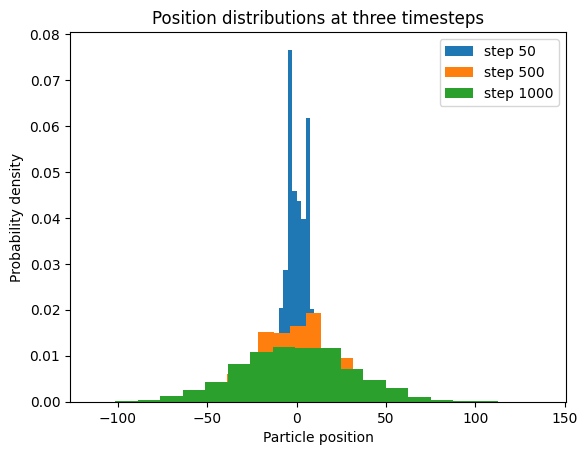

In [10]:
plt.figure()
for step, label in zip([50, 500, -1], ['step 50', 'step 500', 'step 1000']):
    plt.hist( rmulti[:, step], density=True, bins=20, label=label
             )
plt.xlabel('Particle position')
plt.ylabel('Probability density')
plt.title('Position distributions at three timesteps')
plt.legend()
plt.show()

*Your answers to Q1.1 and Q1.2:*

The mean stays the same, the distribution remains symmetric around zero. THe spread grows with as the step increases. THe distribution becomes broader and more diffuse as it spreads outward.

---

## Part 2: Ensemble Mean and Standard Deviation

Instead of snapshots, we can track the **mean** and **standard deviation** of all particle positions *at every step* using `np.mean` and `np.std` with an `axis` argument.

`rmulti` has shape `(Np, Nstep)`. Averaging along `axis=0` collapses the particle dimension and returns one value per step.

> **Q2.1** — Compute `means` and `stds`: arrays of length `Nstep` giving the mean and standard deviation across all particles at each step.

> **Q2.2** — What value do you expect `means` to hover near? Why does the random walk have zero mean regardless of how many steps are taken?

In [13]:
means =np.mean(rmulti, axis=0) # TODO: np.mean of rmulti along axis 0
stds  = np.std(rmulti, axis=0)  # TODO: np.std  of rmulti along axis 0

print(f"Mean position at final step:    {means[-1]:.3f}")
print(f"Std of positions at final step: {stds[-1]:.2f}")

Mean position at final step:    -0.100
Std of positions at final step: 31.23


*Your answers to Q2.1 and Q2.2:*

I expec the maes to hover near 0. A random walk has a zero mean because of it's symmetry as it will be centered at zero.

---

## Part 3: Visualizing the Spread

> **Q3.1** — On a single figure, plot:
> - 20 individual particle trajectories (rows 0–19 of `rmulti`)
> - `means` in black
> - `stds` in blue
>
> Label the axes and add a descriptive title.

> **Q3.2** — Does the standard deviation grow *linearly* (constant speed), *faster*, or *slower* than linear? Make a qualitative judgment from the plot before we verify it analytically.

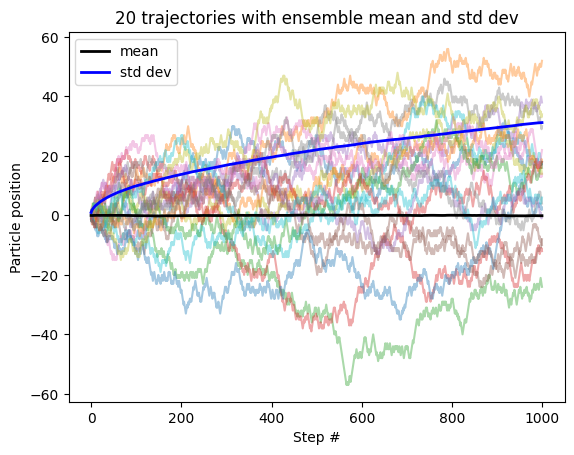

In [14]:
plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.4)
plt.plot(means, 'k-', label='mean',    linewidth=2)
plt.plot(stds,  'b-', label='std dev', linewidth=2)
plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('20 trajectories with ensemble mean and std dev')
plt.legend()
plt.show()

*Your answers to Q3.1 and Q3.2:*

The std deviation grows slower than a linear curve

---

## Part 4: Verifying the $\\sqrt{N}$ Law

The theoretical prediction for the spread of a 1D random walk is

$$\\sigma(n) = \\sqrt{n}$$

where $n$ is the step number.

> **Q4.1** — Create a step array `n = np.arange(1, 1001)` and overlay the curve $\\sqrt{n}$ on the previous figure as a dashed red line. How well does theory match simulation?

> **Q4.2** — What does the $\\sqrt{n}$ growth law imply about how quickly particles spread? To double the spread, how many more steps are needed?

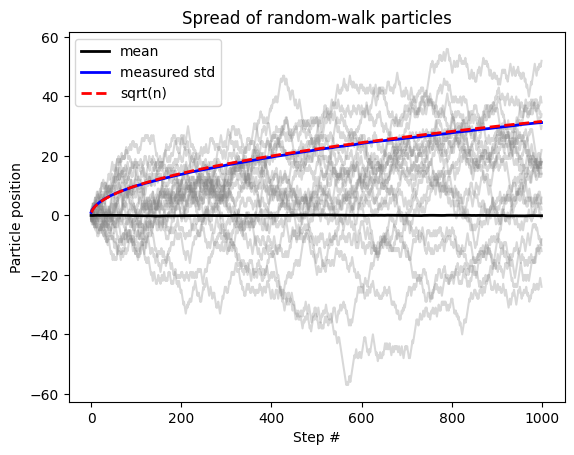

In [15]:
n = np.arange(1, 1001)

plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.3, color='gray')
plt.plot(means, 'k-',   label='mean',          linewidth=2)
plt.plot(stds,  'b-',   label='measured std',  linewidth=2)
plt.plot(n, np.sqrt(n), 'r--', label='sqrt(n)', linewidth=2)
plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('Spread of random-walk particles')
plt.legend()
plt.show()

*Your answers to Q4.1 and Q4.2:*

4.1 the theory matches the simlution really well
4.2 It implies that the spread grows slower than linearly and the standard deviation increases like the square root of n.
to double the spread 4x as many steps are needed.

---

## Part 5: The Binomial Distribution

### Why $\\sqrt{n}$? — A coin-flip model

Every step in a 1D random walk is equivalent to flipping a fair coin: heads $= +1$, tails $= -1$.  
After $n$ flips, the number of heads follows the **binomial distribution**.

NumPy samples from it with:

```python
rng.binomial(n, p, N)
```

- `n` — number of coin flips per experiment  
- `p` — probability of heads  
- `N` — number of independent experiments

> **Q5.1** — Using `n=200, p=0.5`, generate `50` samples and plot a normalized histogram. Where is it centered? Is 50 samples enough to see the shape clearly?

> **Q5.2** — Repeat with `N=100000` samples. What well-known probability distribution does the smooth histogram resemble?

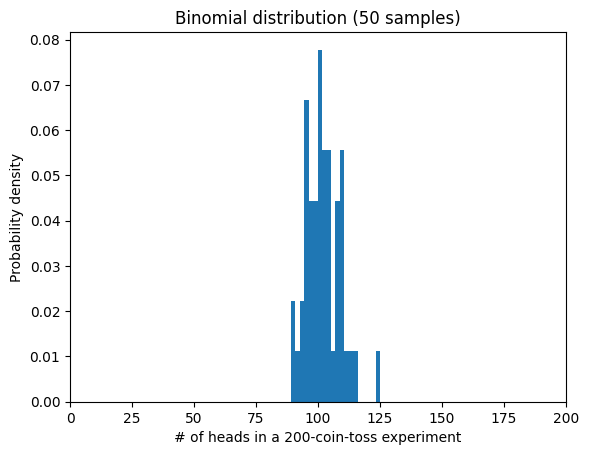

In [21]:
n = 200
p = 0.5

rng = np.random.default_rng()
sample_bino = rng.binomial(n, p, 50)

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (50 samples)')
plt.show()

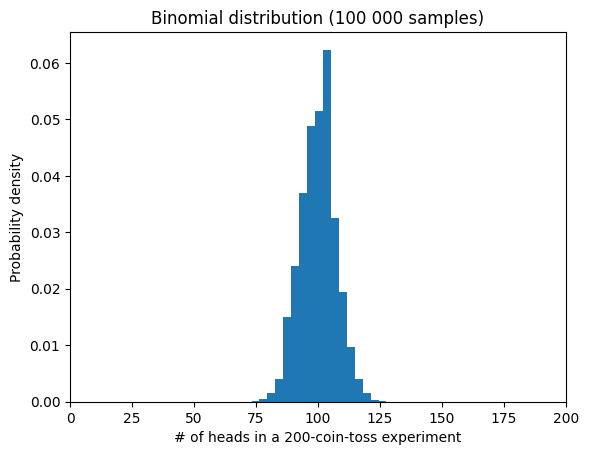

In [24]:
sample_bino = rng.binomial(n, p, 100000
                           )

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (100 000 samples)')
plt.show()

*Your answers to Q5.1 and Q5.2:*

5.1 It is centered at less than 100. No it is not enough to see the shape clearly.
5.2 The histogram represents a normal curve or bell curve

---

## Part 6: Connecting the Binomial Distribution to Random Walk

If a particle flips $n$ coins and gets $k$ heads and $(n-k)$ tails, its final position is

$$x = k \\cdot (+1) + (n - k) \\cdot (-1) = 2k - n.$$

> **Q6.1** — Using `sample_bino` (100 000 samples, `n=200`), compute the random-walk final position `rw` from the formula above. Plot a normalized histogram with `xlim(-n, n)`.

> **Q6.2** — Add two vertical red lines at $x = \\pm\\sqrt{n}$ using `plt.axvline`. Do they align with the spread?

> **Q6.3** — The standard deviation of the binomial is $\\sqrt{n \\cdot p \\cdot (1-p)}$. For $p=0.5$, $n=200$, compute this. After converting to random-walk positions (multiply by 2), what is $\\sigma$? Does it equal $\\sqrt{n}$?

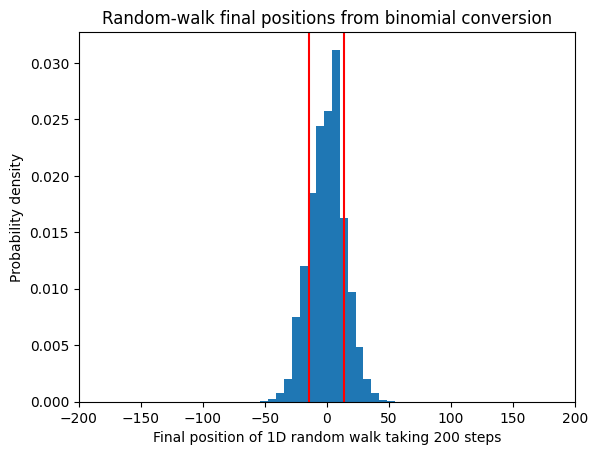

Measured std: 14.08
Expected std (sqrt(n)): 14.14


In [25]:
# Convert heads to random-walk positions
rw = 2 * sample_bino - n  # TODO: apply x = k*(+1) + (n-k)*(-1) using sample_bino

plt.figure()
plt.hist(rw, density=True, bins=20)
plt.xlim(-n, n)
plt.axvline(  np.sqrt(n), color='r'
           )
plt.axvline( -np.sqrt(n), color='r'
           )
plt.xlabel('Final position of 1D random walk taking 200 steps')
plt.ylabel('Probability density')
plt.title('Random-walk final positions from binomial conversion')
plt.show()

print(f"Measured std: {np.std(rw):.2f}")
print(f"Expected std (sqrt(n)): {n**0.5:.2f}")

*Your answers to Q6.1, Q6.2, and Q6.3:*

6.2 Yes the two verticle lines align with the spread

6.3 Binomial std : 7.07
Converted to random walk position = 14.14

sqrt(n) aprox 14.14

yes after the conversion the random walk standard deviation matchees sqrt(n)

---

## Summary Questions

> **S1** — We used `axis=0` in `np.mean(rmulti, axis=0)`. Explain in plain language what dimension is being averaged over and what the resulting array represents.

> **S2** — Suppose we had a biased coin with $p=0.7$ (probability of $+1$ step). Would the mean position still be zero after many steps? What would the spread look like?

> **S3** — An ink drop in still water spreads diffusively. If after 1 second the cloud has radius $r$, how large will it be after 4 seconds?

> **S4** — The binomial distribution approaches a Gaussian as $n \\to \\infty$. This is a special case of the **Central Limit Theorem**. State the CLT in your own words and explain why random walk demonstrates it naturally.

*Your answers:*

**S1:** axis = 0 averages over the particle dimension. For each timestep it computes the mean of all particle position, so the resulting array give sthe ensemble mean position at each step.

**S2:** No the mean position would no longer be zero. with a p = 0.7
 the mean position would grow positively over time so the entire distribution would be shifted over to the right

**S3:** Diffusive spread means radius grows like the square root of time. If the cloud radius is still r at 1 second, after 4 seconds it will be around 2r

**S4:** CLT states that the sum of many independent random variables tends to form a normal distribution regardless of the step distribution. A random walk demonstrates this because its position is the sum of many independent steps +-1 which randomaly occur so as following CLT it will approximately represent a Gaussian as the number of steps grow.